In [1]:
import sys
# Install necessary libraries
!{sys.executable} -m pip install gdown tensorflow

In [2]:
#System & File Handling
import os
import zipfile
import random

#Data downloading
import gdown

#Data analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Image Processing
from PIL import Image

#ML/DL
import tensorflow as tf

## 1. EDA

In [3]:
gdrive_url = 'https://drive.google.com/file/d/19PoAmtvHWrI3M4lGQAHiNVJx30mqVeUU/view?usp=drive_link'
save_zip_as = 'chest_xray_dataset.zip'

print(f"Downloading {gdrive_url} and saving as {save_zip_as}...")
# Download the file
gdown.download(gdrive_url, save_zip_as, fuzzy=True)
print(f"Downloaded to {save_zip_as}")

# Unzip the file
print(f"Unzipping {save_zip_as}...")
with zipfile.ZipFile(save_zip_as, 'r') as zip_ref:
    zip_ref.extractall('.')
print("Unzipping complete.")

# Remove the zip file after extraction to save space
os.remove(save_zip_as)
print(f"Removed {save_zip_as}")

# Define the dataset path after extraction
dataset_path = '/content'
print(f"Extracted dataset should be available at: {dataset_path}")

Downloading...
From (original): https://drive.google.com/uc?id=19PoAmtvHWrI3M4lGQAHiNVJx30mqVeUU
From (redirected): https://drive.google.com/uc?id=19PoAmtvHWrI3M4lGQAHiNVJx30mqVeUU&confirm=t&uuid=f0443659-6500-41f1-b6a0-5c265e95884b
To: /content/chest_xray_dataset.zip
100%|██████████| 1.23G/1.23G [00:14<00:00, 84.8MB/s]


Downloaded to chest_xray_dataset.zip
Unzipping chest_xray_dataset.zip...
Unzipping complete.
Removed chest_xray_dataset.zip
Extracted dataset should be available at: /content


### 1.1 Count Images in Each Class(Pneumonia/Normal) and Split(train/val/test)



In [4]:
def count_images(base_path):
    image_counts = {}
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path):
            print(f"Warning: Split path does not exist: {split_path}")
            continue

        image_counts[split] = {}
        for class_name in ['NORMAL', 'PNEUMONIA']:
            class_path = os.path.join(split_path, class_name)
            if os.path.exists(class_path):
                num_images = len(os.listdir(class_path))
                image_counts[split][class_name] = num_images
            else:
                image_counts[split][class_name] = 0
                print(f"Warning: Class path does not exist: {class_path}")
    return image_counts

print("Counting images...")
counts = count_images(dataset_path)

for split, class_counts in counts.items():
    print(f"\n--- {split.upper()} Set ---")
    total_split_images = 0
    for class_name, count in class_counts.items():
        print(f"  {class_name}: {count} images")
        total_split_images += count
    print(f"  Total for {split}: {total_split_images} images")


Counting images...

--- TRAIN Set ---
  NORMAL: 1341 images
  PNEUMONIA: 3875 images
  Total for train: 5216 images

--- VAL Set ---
  NORMAL: 8 images
  PNEUMONIA: 8 images
  Total for val: 16 images

--- TEST Set ---
  NORMAL: 234 images
  PNEUMONIA: 390 images
  Total for test: 624 images


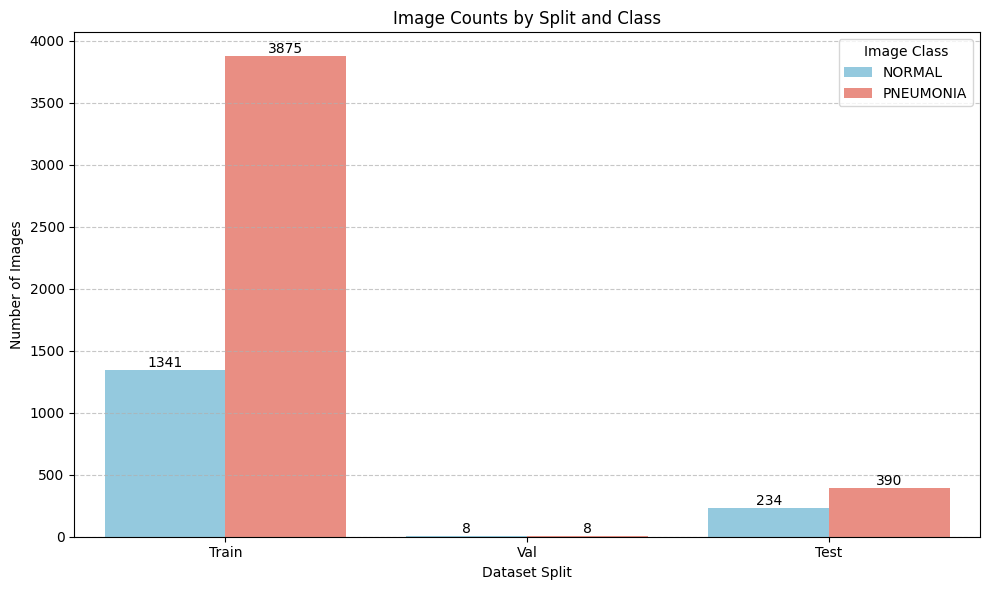

In [5]:
# Prepare data for plotting
plot_data = []
for split, classes in counts.items():
    for class_name, count in classes.items():
        plot_data.append({'Split': split.capitalize(), 'Class': class_name, 'Count': count})

df_counts = pd.DataFrame(plot_data)

# Create the bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Split', y='Count', hue='Class', data=df_counts, palette={'NORMAL': 'skyblue', 'PNEUMONIA': 'salmon'})
plt.title('Image Counts by Split and Class')
plt.xlabel('Dataset Split')
plt.ylabel('Number of Images')
plt.legend(title='Image Class')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add count labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

### Findings
Class imbalance problem exists in Train and Test set.

In Train-set, there are almost 3 times more pneumonia cases than normal cases and in Test-set,number of pneumonia cases is almost 1.6 times more than normal.This may lead to wrong predictions in the case of minority class(Normal).

Moreover,The validation set is balanced but extremely small. It might not fully represent the overall data variability.

### 1.2 Visualize Sample Images



Displaying sample images...


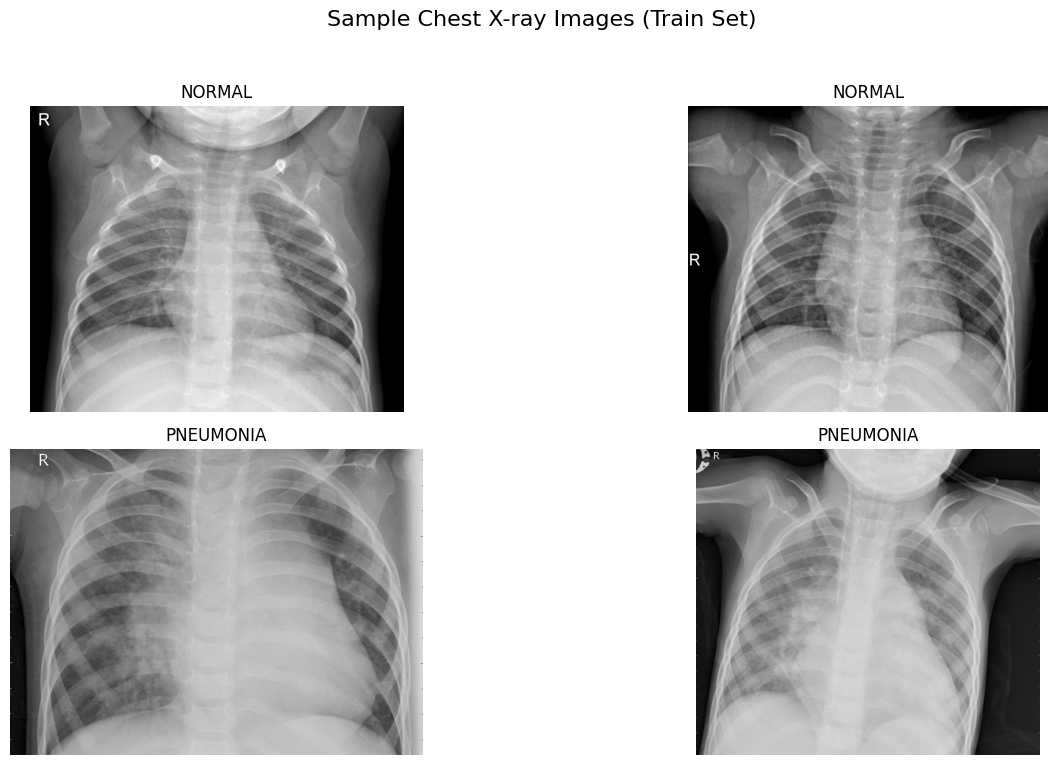

In [6]:
def display_sample_images(base_path, num_samples=2):
    plt.figure(figsize=(15, 8))
    plot_idx = 1

    for class_name in ['NORMAL', 'PNEUMONIA']:
        class_path = os.path.join(base_path, 'train', class_name)
        if not os.path.exists(class_path):
            print(f"Skipping {class_name} samples: path not found {class_path}")
            continue

        image_files = [file for file in os.listdir(class_path) if file.lower().endswith(('.png', '.jpg', '.jpeg'))]
        selected_images = random.sample(image_files, min(num_samples, len(image_files)))

        for img_file in selected_images:
            img_path = os.path.join(class_path, img_file)
            try:
                img = Image.open(img_path)
                plt.subplot(2, num_samples, plot_idx)
                plt.imshow(img, cmap='gray')
                plt.title(f"{class_name}")
                plt.axis('off')
                plot_idx += 1
            except Exception as e:
                print(f"Could not load image {img_file}: {e}")

    plt.suptitle("Sample Chest X-ray Images (Train Set)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("Displaying sample images...")
display_sample_images(dataset_path)

### 1.3 Analyze Image Resolution and Aspect Ratio

In [7]:
image_stats = []

for split_name, class_counts_in_split in counts.items(): # Using 'counts' from a previous cell
    for class_name in class_counts_in_split.keys():
        class_path = os.path.join(dataset_path, split_name, class_name)
        if os.path.exists(class_path):
            for img_file in os.listdir(class_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_path, img_file)
                    try:
                        with Image.open(img_path) as img:
                            width, height = img.size
                            aspect_ratio = width / height
                            image_stats.append({
                                'Split': split_name.capitalize(),
                                'Class': class_name,
                                'Filename': img_file,
                                'Width': width,
                                'Height': height,
                                'Aspect_Ratio': aspect_ratio
                            })
                    except Exception as e:
                        print(f"Could not process image {img_path}: {e}")

df = pd.DataFrame(image_stats)

print("Images with Highest and Lowest Aspect Ratios per Split and Class:")

results = []

for split_name in df['Split'].unique():
    for class_name in df['Class'].unique():
        filtered_df = df[(df['Split'] == split_name) & (df['Class'] == class_name)]

        if not filtered_df.empty:
            # Highest Aspect Ratio
            highest_ar_row = filtered_df.loc[filtered_df['Aspect_Ratio'].idxmax()]
            results.append(highest_ar_row.to_dict())

            # Lowest Aspect Ratio
            lowest_ar_row = filtered_df.loc[filtered_df['Aspect_Ratio'].idxmin()]
            results.append(lowest_ar_row.to_dict())

if results:
    df_to_show = pd.DataFrame(results)
    df_to_show.index = df_to_show.index + 1 # Make index 1-based
    display(df_to_show)
else:
    print("No image statistics found to display.")


Images with Highest and Lowest Aspect Ratios per Split and Class:


,Split,Class,Filename,Width,Height,Aspect_Ratio
1,Train,NORMAL,IM-0199-0001.jpeg,1506,833,1.807923
2,Train,NORMAL,NORMAL2-IM-0818-0001-0002.jpeg,1679,1914,0.877220
3,Train,PNEUMONIA,person325_virus_661.jpeg,446,132,3.378788
4,Train,PNEUMONIA,person1147_virus_1917.jpeg,1624,1944,0.835391
5,Val,NORMAL,NORMAL2-IM-1436-0001.jpeg,1288,928,1.387931
6,Val,NORMAL,NORMAL2-IM-1437-0001.jpeg,1240,1104,1.123188
7,Val,PNEUMONIA,person1947_bacteria_4876.jpeg,1152,664,1.734940
8,Val,PNEUMONIA,person1952_bacteria_4883.jpeg,1192,952,1.252101
9,Test,NORMAL,IM-0022-0001.jpeg,1300,617,2.106969
10,Test,NORMAL,NORMAL2-IM-0030-0001.jpeg,2517,2713,0.927755


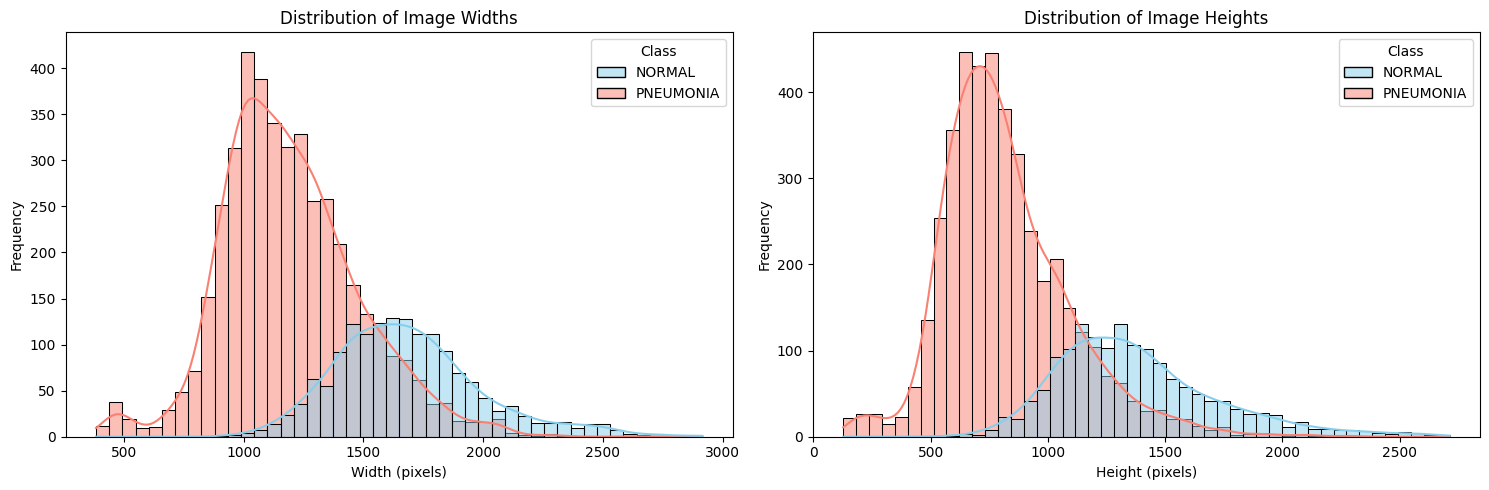

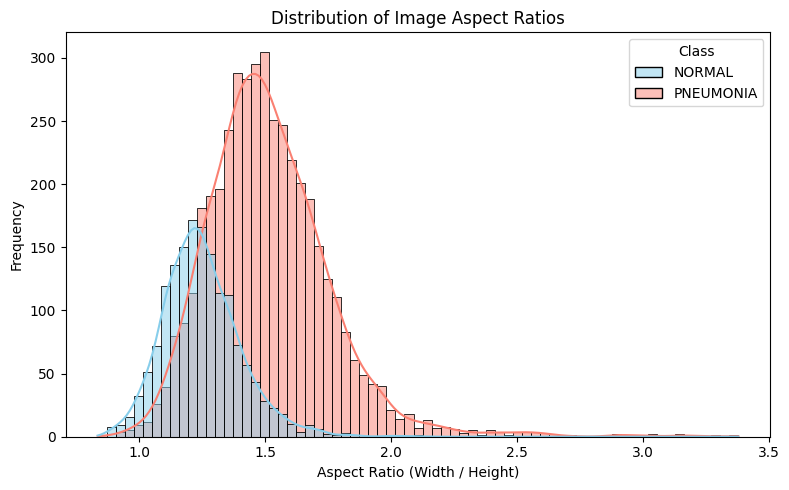

In [8]:
plt.figure(figsize=(15, 5))

# Distribution of Image Widths
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Width', hue='Class', kde=True, palette={'NORMAL': 'skyblue', 'PNEUMONIA': 'salmon'})
plt.title('Distribution of Image Widths')
plt.xlabel('Width (pixels)')
plt.ylabel('Frequency')

# Distribution of Image Heights
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='Height', hue='Class', kde=True, palette={'NORMAL': 'skyblue', 'PNEUMONIA': 'salmon'})
plt.title('Distribution of Image Heights')
plt.xlabel('Height (pixels)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Aspect_Ratio', hue='Class', kde=True, palette={'NORMAL': 'skyblue', 'PNEUMONIA': 'salmon'})
plt.title('Distribution of Image Aspect Ratios')
plt.xlabel('Aspect Ratio (Width / Height)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 2. Preprocessing

### 2.1 Define Image Dimensions and Batch Size

In [9]:
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

print(f"Image height: {IMG_HEIGHT}, Image width: {IMG_WIDTH}, Batch size: {BATCH_SIZE}")

Image height: 150, Image width: 150, Batch size: 32


### 2.2 Image Resizing and Pixel Normalization


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Create an ImageDataGenerator instance for preprocessing
# We'll use this for both training and validation/test data for resizing and normalization

image_processor = ImageDataGenerator(
    rescale=1./255 # Normalizes pixel values
)

print("ImageDataGenerator created for resizing and normalization.")

ImageDataGenerator created for resizing and normalization.



*   **Resizing Images :** CNNs require a fixed input size.

*   **Pixel Normalization (`rescale=1./255`):** Scale down pixel values from the range 0-255 into the range 0-1.
    
    This helps the CNN converge faster and train more stably. Larger input values can lead to larger gradients, which can make the training process unstable and slow down learning.


### 2.3 Data Augmentation in Train Data


In [11]:
# ImageDataGenerator for training data with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,                 # Normalize pixel values
    rotation_range=20,              # Randomly rotate images by up to 20 degrees
    width_shift_range=0.1,          # Randomly shift images horizontally by up to 10% of the width
    height_shift_range=0.1,         # Randomly shift images vertically by up to 10% of the height
    shear_range=0.1,                # Apply shear transformation by up to 10%
    zoom_range=0.1,                 # Randomly zoom in on images by up to 10%
    horizontal_flip=True,           # Randomly flip images horizontally
    fill_mode='nearest'             # Strategy for filling in newly created empty pixels with the value of the nearest existing pixel.
    # Other fill_mode options include 'constant' (filling with a constant value like black), 'reflect' (reflecting pixels across the boundary), or 'wrap' (wrapping pixels from the opposite edge)
)

# ImageDataGenerator for validation/test data (only resizing and normalization, no augmentation)
# It's crucial NOT to apply augmentation to validation/test sets to get an unbiased evaluation.
validation_test_datagen = ImageDataGenerator(rescale=1./255)

print("ImageDataGenerators created for training (with augmentation) and validation/test (without augmentation).")

ImageDataGenerators created for training (with augmentation) and validation/test (without augmentation).


### 2.4 Create Data Generators


In [12]:
# Define paths for each dataset split
train_path = os.path.join(dataset_path, 'train')
val_path = os.path.join(dataset_path, 'val')
test_path = os.path.join(dataset_path, 'test')

# Training data generator with augmentation
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary' # Because we have two classes (NORMAL/PNEUMONIA)
)

# Validation data generator without augmentation
validation_generator = validation_test_datagen.flow_from_directory(
    val_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Keep data in order for consistent evaluation
)

# Test data generator without augmentation
test_generator = validation_test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Keep data in order for consistent evaluation
)

print("Data generators created for train, validation, and test sets.")
print(f"Classes found: {train_generator.class_indices}")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Data generators created for train, validation, and test sets.
Classes found: {'NORMAL': 0, 'PNEUMONIA': 1}


## 3. Model Development



### 3.1 Design a Basic CNN Model

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

print("TensorFlow and Keras libraries imported.")

TensorFlow and Keras libraries imported.


### Convolutional Layer (Conv2D)
Seeing details by appying a tiny filter (or kernel) which slides across the entire image to detect specific features, such as edges, textures, or patterns.

By applying multiple filters, the convolutional layer learns a **hierarchy of features** from the raw pixel data. Early layers might detect simple features like lines, while deeper layers combine these to detect more complex shapes and objects (e.g., a lung outline).


In [14]:
model = Sequential([
    tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)), # Param: input shape
    Conv2D(32, (3, 3), activation='relu') # Param: Num_of_filter,kernel_size(size of window)
])

print("First Convolutional Layer added to the model.")

First Convolutional Layer added to the model.


### Max Pooling Layer (MaxPooling2D)

The feature maps(highlighted edges) produced in the convolutional layer is shrinked by taking the maximum value in a small window (e.g., 2x2).

Thus, **dimensionality reduction** of the feature maps which decreases the computational cost and **robustness** i.e: pooling capture a feature even with slight shifts or distortions in the input is achieved.


In [15]:
model.add(MaxPooling2D((2, 2)))

# Adding more Conv2D and MaxPooling2D layers to learn more complex features
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2))) #param: pool_size(size of the window)

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2))) #param: pool_size(size of the window)

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2))) #param: pool_size(size of the window)

print("Max Pooling layers and additional Convolutional layers added.")

Max Pooling layers and additional Convolutional layers added.


### Flatten Layer
As the subsequent dense (fully connected) layers expect a 1D input,flatten layer takes the multi-dimensional output from the convolutional and pooling layers and transforms it into a one-dimensional vector.



In [16]:
model.add(Flatten())

print("Flatten layer added.")

Flatten layer added.


### Dense Layers (Fully Connected Layers)

These are standard neural network layers where every neuron in one layer is connected to every neuron in the next layer. They perform classification based on flatten features.

In hidden dense layer the, `relu` activation helps in learning non-linear relationships. And in output dense layer,a single neuron with a `sigmoid` activation function outputs a probability between 0 and 1.


In [17]:
model.add(Dense(128, activation='relu')) #Params: units(num_of_neurons in a layer), activation = relu for hidden layer
model.add(Dropout(0.5)) # Adding a Dropout layer to prevent overfitting

print("Dense hidden layer and Dropout layer added.")

Dense hidden layer and Dropout layer added.


In [18]:
model.add(Dense(1, activation='sigmoid')) # Output layer for binary classification, activation = sigmoid for output ;ayer

print("Dense output layer added.")

Dense output layer added.


### 3.2 Compile CNN Model

**binary_crossentropy:** This loss function specifically designed for binary classification. It heavily penalizes predictions that are confident but wrong. For example, if the true label is 1 but the model predicts 0.1 (very confident it's 0), the loss will be high. If the true label is 1 and the model predicts 0.9, the loss will be low.

**Adam (Adaptive Moment Estimation)**:Unlike traditional SGD (Stochastic Gradient Descent) which uses a single learning rate for all weight updates, this optimization algorithm computes adaptive learning rates for each parameter.

In [19]:
# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()])

# Display the model summary
print("Model compiled. Here is the summary:")
model.summary()

Model compiled. Here is the summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,043,905 (3.98 MB)

 Trainable params: 1,043,905 (3.98 MB)

 Non-trainable params: 0 (0.00 B)

### 3.3. Model Training

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

EPOCHS = 25

# Define Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restores model weights from the epoch with the best value of the monitored quantity.
)

model_checkpoint = ModelCheckpoint(
    'best_model.keras',  # Name of the file to save the model
    monitor='val_loss',  # Monitor validation loss
    save_best_only=True, # Only save when val_loss improves
    mode='min'           # 'min' for val_loss means we want the minimum loss
)

print(f"Starting model training for {EPOCHS} epochs with EarlyStopping and ModelCheckpoint...")

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[early_stopping, model_checkpoint]
)

print("Model training complete.")

Starting model training for 25 epochs with EarlyStopping and ModelCheckpoint...
Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 454ms/step - accuracy: 0.7454 - auc: 0.6238 - loss: 0.5589 - precision: 0.7557 - recall: 0.9714 - val_accuracy: 0.5000 - val_auc: 0.7656 - val_loss: 0.7499 - val_precision: 0.5000 - val_recall: 0.8750
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 434ms/step - accuracy: 0.7853 - auc: 0.8119 - loss: 0.4451 - precision: 0.8088 - recall: 0.9311 - val_accuracy: 0.7500 - val_auc: 0.8594 - val_loss: 0.6223 - val_precision: 0.7000 - val_recall: 0.8750
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 433ms/step - accuracy: 0.8717 - auc: 0.9198 - loss: 0.3108 - precision: 0.9001 - recall: 0.9306 - val_accuracy: 0.9375 - val_auc: 0.9688 - val_loss: 0.2783 - val_precision: 0.8889 - val_recall: 1.0000
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 425ms/step - accuracy: 0.8896 - auc: 0.9412 - loss: 0.2655 - precision: 0.9150 - recall: 0.9386 - val_accuracy: 0.7500 - val_auc: 1.0000 - va

### 3.4 Monitor Overfitting

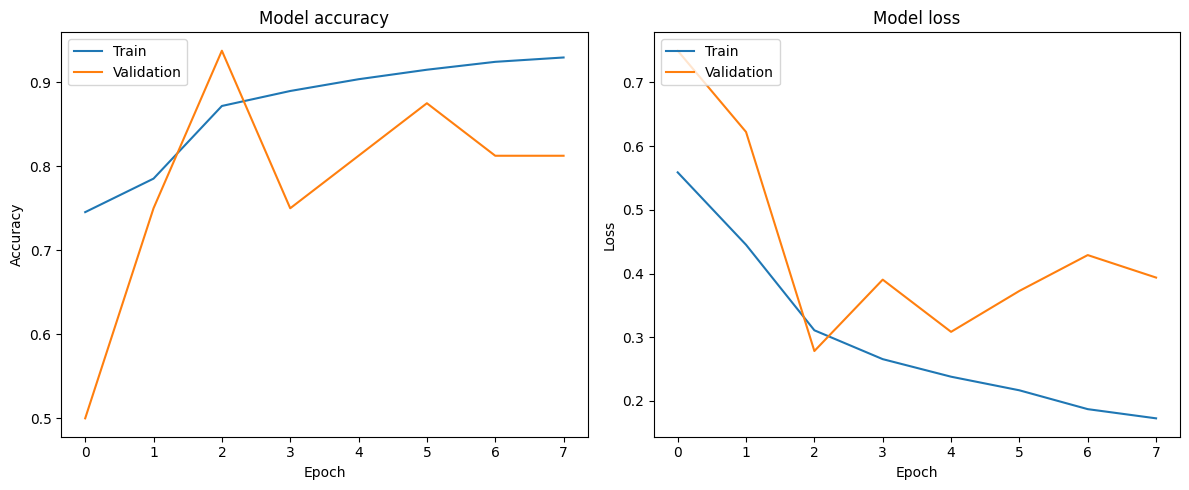

These plots show the training and validation accuracy and loss over epochs. 
If the training loss continues to decrease while validation loss starts to increase, 
it's an indicator of overfitting.


In [21]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

print("These plots show the training and validation accuracy and loss over epochs. \nIf the training loss continues to decrease while validation loss starts to increase, \nit's an indicator of overfitting.")


**Identifying Overfitting or Underfitting**

Overfitting: This occurs when model learns the training data too well, including its noise,so it performs poorly on new, unseen data (like our validation set).

There are clear signs of overfitting.
Training loss continues to decrease, but validation loss starts to increase or fluctuates significantly.
Similarly,Training accuracy continues to improve, but validation accuracy stops improving rather decreases,plateus and fluctuates.This indicates the model is memorizing the training examples rather than learning generalizable patterns.

The early stopping mechanism correctly intervened to prevent further deterioration on the validation set.

Underfitting: This happens when both training and validation loss remain high and both training and validation accuracy remain low, model is too simple to capture the underlying patterns in the data. It performs poorly on both the training and unseen data.

So, our model is definitely not underfitting, as its training performance is very good.It'ss overfitting.

### 3.5 Model Evaluation

#### Understanding Evaluation Metrics in Medical Context

*   **Accuracy:** The proportion of correctly classified cases (both normal and pneumonia) out of all cases. A high accuracy might hide poor performance on the minority class(Normal).

*   **Precision (Positive Predictive Value - PPV):** Out of all predicted positive(pneumonia) cases, how many were actually positive. High precision means fewer false positives.(actual not pneumonia i.e: healthy patient is incorrectly diagnosed with pneumonia) This can lead to unnecessary anxiety, or even inappropriate treatment.
*   **Recall (Sensitivity or True Positive Rate - TPR):** Out of all actual positive(pneumonia) cases, how many were correctly identified as positive. High recall means fewer false negatives(actual pneumonia patient is incorrectly diagnosed as healthy) This is often the more critical error, as it can lead to delayed or missed treatment, potentially worsening the patient's condition and leading to severe health consequences or even death.

*   **F1-Score:** The harmonic mean of precision and recall. It balances both precision and recall, useful especially in situations where we want to avoid both false positives and false negatives to a reasonable degree.
*   **AUC (Area Under(Receiver Operating Characteristic) Curve):**
    *   **Definition:** Measures the ability of the model to distinguish between positive and negative classes across various classification thresholds. A high AUC indicates that the model is good at separating healthy individuals from those with pneumonia. It's particularly robust to class imbalance and provides a comprehensive view of the model's discriminative power.

*   **Confusion Matrix:** A table that summarizes the performance of a classification model. It shows the number of True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).

    This is arguably the most informative metric as it provides a detailed breakdown of where the model is succeeding and failing.

Evaluating model on test data...
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.8526 - auc: 0.9251 - loss: 0.3512 - precision: 0.8531 - recall: 0.9231

Test Loss: 0.3512
Test Accuracy: 0.8526
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 249ms/step

Calculated Metrics:
Accuracy: 0.8526
Precision: 0.8531
Recall: 0.9231
F1-Score: 0.8867
AUC: 0.9253


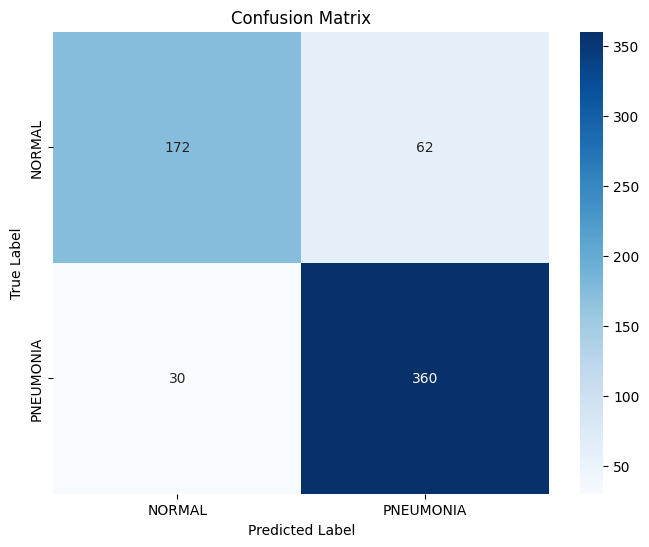

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("Evaluating model on test data...")

# Evaluate the model on the test set
loss, accuracy, precision_metric, recall_metric, auc_metric = model.evaluate(test_generator)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Get predictions for the test set
test_generator.reset()
Y_pred_proba = model.predict(test_generator)
Y_pred = (Y_pred_proba > 0.5).astype(int)

# Get true labels from the test generator
Y_true = test_generator.classes

# Calculate additional metrics
acc = accuracy_score(Y_true, Y_pred)
prec = precision_score(Y_true, Y_pred)
rec = recall_score(Y_true, Y_pred)
f1 = f1_score(Y_true, Y_pred)
auc = roc_auc_score(Y_true, Y_pred_proba)
conf_matrix = confusion_matrix(Y_true, Y_pred)

print(f"\nCalculated Metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#### Model Performance Interpretation

**Evaluation Metrics**

This model achieved a Test Accuracy of **0.8526** and a Test Loss of **0.3512**, which are generally good indicators.


Precision (**0.8531**): Out of all cases predicted as Pneumonia, **85.31%** were truly Pneumonia. This means about 14.69% of the positive predictions were false positives (healthy patients incorrectly diagnosed with Pneumonia).


Recall (**0.9231**): Out of all actual Pneumonia cases, **92.31%** were correctly identified. This is an excellent recall score, meaning our model is very good at catching true Pneumonia cases, leading to a low rate of false negatives (Pneumonia patients incorrectly diagnosed as Normal).

F1-Score (**0.8867**): This is the harmonic mean of precision and recall, providing a balanced measure . A high F1-Score indicates a good balance between avoiding both false positives and false negatives.

AUC (**0.9253**): The Area Under the Receiver Operating Characteristic (ROC) curve is a robust metric, especially with imbalanced datasets. An AUC of **0.9253** is excellent, suggesting the model has a very good ability to distinguish between Normal and Pneumonia cases across various probability thresholds.

Confusion Matrix:

True Positives (TP): **360** (Correctly identified Pneumonia cases)

True Negatives (TN): **172** (Correctly identified Normal cases)

False Positives (FP): **62** (Healthy patients incorrectly flagged as Pneumonia).The **62** False Positives are a concern but often preferable to missed diagnoses which can be determined through further diagnosis.

False Negatives (FN): **30** (Pneumonia patients incorrectly flagged as Normal). The low number of False Negatives (**30**) is a strong point for a medical diagnostic model.



**Measures for Improvements**

The signs of overfitting and the nature of the dataset (especially the small, imbalanced validation set), here are some measures that can be taken:

* Increase Validation Set Size & Re-evaluate Data Splitting: The validation set of only 16 images (8 normal, 8 pneumonia) is extremely small. Validation metrics from such a small set can be very noisy and unreliable, making early stopping less effective and making it hard to trust the reported val_loss and val_accuracy.


* Addressing Class Imbalance in Training: Although recall is good, the training set has a significant imbalance (3875 Pneumonia vs. 1341 Normal). we can explicitly handle this during training by using class_weight in model.fit. This assigns a higher penalty to errors on the minority class during training.


* Advanced Regularization Techniques:
  
  * Batch Normalization: Adding BatchNormalization layers after convolutional layers can help stabilize and accelerate training, and also acts as a form of regularization to reduce overfitting.

  * L2 Regularization (Weight Decay): Apply L2 regularization to  convolutional and dense layers to penalize large weights.

  * More Aggressive Data Augmentation: While  using augmentation, increasing the ranges for rotation_range width_shift_range, height_shift_range, shear_range, and zoom_range can be considered if appropriate for chest X-ray images. Adding vertical_flip=True (if vertical symmetry is valid for X-rays) could also be an option.


* Transfer Learning with Pre-trained Models: For image classification tasks, especially with limited data or when aiming for state-of-the-art performance, using pre-trained models (e.g., VGG16, ResNet50, MobileNetV2) is often highly effective. we can load a model pre-trained on a large dataset like ImageNet and fine-tune it on your chest X-ray data. This leverages features learned from a vast image corpus.

* Hyperparameter Tuning: Systematically experiment with different hyperparameters for model and optimizer (e.g., learning rate, number of filters, dropout rates, optimizer choice).


## 4. Data Re-splitting for Robust Evaluation

#### As the current validation set is too small (16 images) to provide reliable metrics and effectively guide model training. To address this, we will implement a new data splitting strategy:

1.  **Consolidate `val` and `test` sets:** The existing `val` (16 images) and `test` (624 images) directories will be merged into a single `new_test` directory. This creates a larger set for final, unbiased evaluation.
2.  **Create a new `validation` set from the original `train` data:** A portion of the original training data (e.g., 20%) will be moved to a `new_val` directory. This ensures the validation set is sufficiently large and representative to properly monitor model performance during training.

This approach will provide more stable validation metrics and allow for a more accurate assessment of model improvements.

In [23]:
import shutil

# Define paths based on previous extraction
original_train_path = os.path.join(dataset_path, 'train')
original_val_path = os.path.join(dataset_path, 'val')
original_test_path = os.path.join(dataset_path, 'test')

# Define new paths
new_base_path = os.path.join(dataset_path, 're_split_data')
new_train_path = os.path.join(new_base_path, 'train')
new_val_path = os.path.join(new_base_path, 'val')
new_test_path = os.path.join(new_base_path, 'test')

# Create new base directory
if os.path.exists(new_base_path):
    shutil.rmtree(new_base_path)
os.makedirs(new_train_path)
os.makedirs(new_val_path)
os.makedirs(new_test_path)

def move_files(src_dir, dst_dir):
    for root, _, files in os.walk(src_dir):
        relative_path = os.path.relpath(root, src_dir)
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                src_file = os.path.join(root, file)
                dst_subdir = os.path.join(dst_dir, relative_path)
                os.makedirs(dst_subdir, exist_ok=True)
                shutil.copy(src_file, dst_subdir)

print("--- Consolidating validation and test sets into new_test ---")
# Copy original val and test data to new_test
move_files(original_val_path, new_test_path)
move_files(original_test_path, new_test_path)
print(f"Combined original val and test sets into {new_test_path}")

print("--- Splitting new validation set from original training data ---")
# Iterate through class subdirectories in original_train_path
for class_name in os.listdir(original_train_path):
    class_src_path = os.path.join(original_train_path, class_name)
    if os.path.isdir(class_src_path):
        files = [f for f in os.listdir(class_src_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        random.shuffle(files)

        # Determine split size (e.g., 20% for validation, 80% for new train)
        val_split_size = int(len(files) * 0.2)

        val_files = files[:val_split_size]
        train_files = files[val_split_size:]

        # Copy to new validation path
        new_val_class_path = os.path.join(new_val_path, class_name)
        os.makedirs(new_val_class_path, exist_ok=True)
        for f in val_files:
            shutil.copy(os.path.join(class_src_path, f), new_val_class_path)

        # Copy to new training path
        new_train_class_path = os.path.join(new_train_path, class_name)
        os.makedirs(new_train_class_path, exist_ok=True)
        for f in train_files:
            shutil.copy(os.path.join(class_src_path, f), new_train_class_path)

print(f"New training data in {new_train_path}")
print(f"New validation data in {new_val_path}")
print("Data re-splitting complete. Original directories are unchanged.")

# Update dataset_path to use the new re_split_data for subsequent steps
dataset_path = new_base_path
print(f"Updated dataset_path to: {dataset_path}")


--- Consolidating validation and test sets into new_test ---
Combined original val and test sets into /content/re_split_data/test
--- Splitting new validation set from original training data ---
New training data in /content/re_split_data/train
New validation data in /content/re_split_data/val
Data re-splitting complete. Original directories are unchanged.
Updated dataset_path to: /content/re_split_data


### 4.1 Verify New Data Split Counts

Let's verify the number of images in each new split to ensure the re-splitting was successful and our validation set is now larger.

Counting images in new data splits...

--- TRAIN Set ---
  NORMAL: 1073 images
  PNEUMONIA: 3100 images
  Total for train: 4173 images

--- VAL Set ---
  NORMAL: 268 images
  PNEUMONIA: 775 images
  Total for val: 1043 images

--- TEST Set ---
  NORMAL: 242 images
  PNEUMONIA: 398 images
  Total for test: 640 images


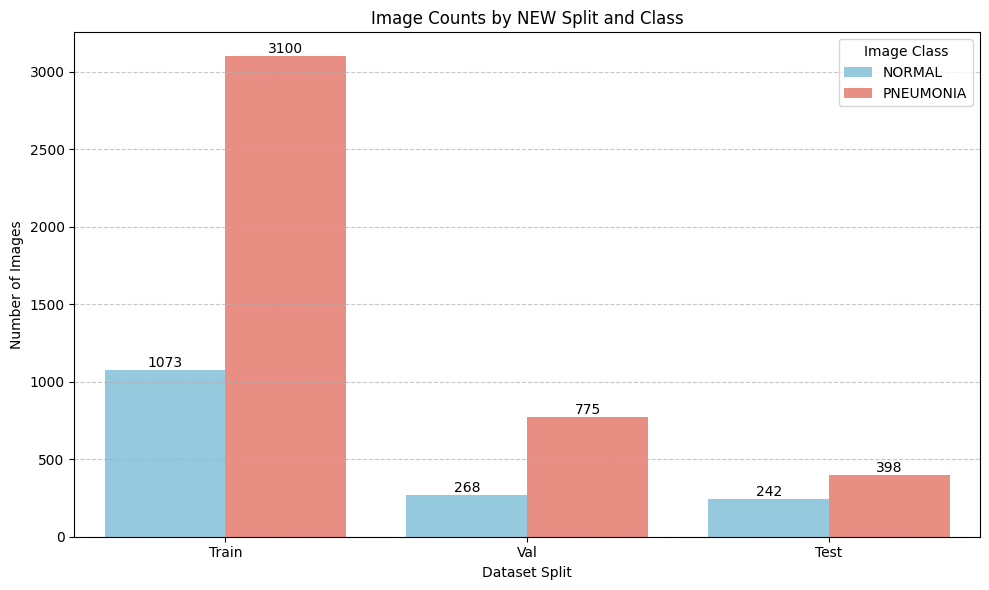

In [24]:
# Re-using the count_images function with the updated dataset_path
print("Counting images in new data splits...")
new_counts = count_images(dataset_path)

for split, class_counts in new_counts.items():
    print(f"\n--- {split.upper()} Set ---")
    total_split_images = 0
    for class_name, count in class_counts.items():
        print(f"  {class_name}: {count} images")
        total_split_images += count
    print(f"  Total for {split}: {total_split_images} images")

# Prepare data for plotting the new counts
plot_data_new = []
for split, classes in new_counts.items():
    for class_name, count in classes.items():
        plot_data_new.append({'Split': split.capitalize(), 'Class': class_name, 'Count': count})

df_counts_new = pd.DataFrame(plot_data_new)

# Create the bar plot for new counts
plt.figure(figsize=(10, 6))
ax_new = sns.barplot(x='Split', y='Count', hue='Class', data=df_counts_new, palette={'NORMAL': 'skyblue', 'PNEUMONIA': 'salmon'})
plt.title('Image Counts by NEW Split and Class')
plt.xlabel('Dataset Split')
plt.ylabel('Number of Images')
plt.legend(title='Image Class')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add count labels on top of each bar
for container in ax_new.containers:
    ax_new.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()


### 4.2 Re-create Data Generators with New Paths

Now that the data has been re-split, we need to create new `ImageDataGenerator` instances that point to these updated directories. The `IMG_WIDTH`, `IMG_HEIGHT`, and `BATCH_SIZE` will remain the same. The augmentation strategy for the training data will also remain unchanged, and validation/test data will still only be rescaled.

In [25]:
# Define paths for each new dataset split
new_train_path = os.path.join(dataset_path, 'train')
new_val_path = os.path.join(dataset_path, 'val')
new_test_path = os.path.join(dataset_path, 'test')

# Training data generator with augmentation (using existing train_datagen)
new_train_generator = train_datagen.flow_from_directory(
    new_train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# Validation data generator without augmentation (using existing validation_test_datagen)
new_validation_generator = validation_test_datagen.flow_from_directory(
    new_val_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Keep data in order for consistent evaluation
)

# Test data generator without augmentation (using existing validation_test_datagen)
new_test_generator = validation_test_datagen.flow_from_directory(
    new_test_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Keep data in order for consistent evaluation
)

print("New data generators created for train, validation, and test sets.")
print(f"Classes found: {new_train_generator.class_indices}")


Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 640 images belonging to 2 classes.
New data generators created for train, validation, and test sets.
Classes found: {'NORMAL': 0, 'PNEUMONIA': 1}


### 4.3 Address Class Imbalance with Class Weights

To mitigate the class imbalance problem, especially evident in the training set (more PNEUMONIA cases than NORMAL), we will calculate class weights. These weights will be used during model training to assign a higher penalty to errors on the minority class, ensuring the model learns equally well from both classes.

In [26]:
from sklearn.utils import class_weight

# Get class labels from the training generator
labels = new_train_generator.classes

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

# Convert to a dictionary for Keras
class_weights_dict = dict(enumerate(class_weights))

print("Calculated Class Weights:")
print(class_weights_dict)


Calculated Class Weights:
{0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


## 5. Model Improvement (with Improved Data Split and Class Weights)



### 5.1 Define and Compile Improved CNN Model

We will re-define the model with Batch Normalization and L2 regularization layers. Batch Normalization helps stabilize and speed up training, while L2 regularization discourages large weights to prevent overfitting.
*   **Batch Normalization** normalizes the inputs to a layer, reducing internal covariate shift and acting as a form of regularization.
*   **L2 Regularization** adds a penalty to the loss function based on the square of the weights' magnitudes, pushing them towards smaller values and simplifying the model.


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers

# Re-initialize the model for the improved version
model_improved = Sequential([
    tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name='input_layer'),

    # First block: Conv -> BN -> ReLU -> Pool
    Conv2D(32, (3, 3), kernel_regularizer=regularizers.l2(0.001), name='conv2d_1'),
    BatchNormalization(name='bn_1'),
    tf.keras.layers.Activation('relu', name='relu_1'),
    MaxPooling2D((2, 2), name='pool_1'),

    # Second block: Conv -> BN -> ReLU -> Pool
    Conv2D(64, (3, 3), kernel_regularizer=regularizers.l2(0.001), name='conv2d_2'),
    BatchNormalization(name='bn_2'),
    tf.keras.layers.Activation('relu', name='relu_2'),
    MaxPooling2D((2, 2), name='pool_2'),

    # Third block: Conv -> BN -> ReLU -> Pool
    Conv2D(128, (3, 3), kernel_regularizer=regularizers.l2(0.001), name='conv2d_3'),
    BatchNormalization(name='bn_3'),
    tf.keras.layers.Activation('relu', name='relu_3'),
    MaxPooling2D((2, 2), name='pool_3'),

    # Fourth block: Conv -> BN -> ReLU -> Pool
    Conv2D(128, (3, 3), kernel_regularizer=regularizers.l2(0.001), name='conv2d_4'),
    BatchNormalization(name='bn_4'),
    tf.keras.layers.Activation('relu', name='relu_4'),
    MaxPooling2D((2, 2), name='pool_4'),

    Flatten(name='flatten'),

    # Dense layers with L2 regularization and Dropout
    Dense(128, kernel_regularizer=regularizers.l2(0.001), name='dense_1'),
    BatchNormalization(name='bn_dense_1'), # Batch norm before activation for dense layer
    tf.keras.layers.Activation('relu', name='relu_dense_1'),
    Dropout(0.5, name='dropout_1'),

    Dense(1, activation='sigmoid', name='dense_2') # Output layer
])

# Compile the improved model
model_improved.compile(optimizer='adam',
                       loss='binary_crossentropy',
                       metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()])

print("Improved CNN Model with Batch Normalization and L2 Regularization created and compiled with named layers.")
model_improved.summary()


Improved CNN Model with Batch Normalization and L2 Regularization created and compiled with named layers.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 148, 148, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 72, 72, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 72, 72, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 34, 34, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 34, 34, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 15, 15, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_4 (Activation)             │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_4 (MaxPooling2D)           │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_1 (BatchNormalization) │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,045,825 (3.99 MB)

 Trainable params: 1,044,865 (3.99 MB)

 Non-trainable params: 960 (3.75 KB)

### 5.2 Train Improved CNN Model with Class Weights


In [28]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

EPOCHS_IMPROVED = 50 # Increase epochs as regularization might slow down convergence initially

# Define Callbacks for the improved model
early_stopping_improved = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Increased patience for potentially slower convergence
    restore_best_weights=True  # Restores model weights from the epoch with the best value
)

model_checkpoint_improved = ModelCheckpoint(
    'best_model_improved.keras',  # New filename for the improved model
    monitor='val_loss',           # Monitor validation loss
    save_best_only=True,          # Only save when val_loss improves
    mode='min'                    # 'min' for val_loss
)

print(f"Starting improved model training for {EPOCHS_IMPROVED} epochs with EarlyStopping and ModelCheckpoint...")

history_improved = model_improved.fit(
    new_train_generator,
    steps_per_epoch=len(new_train_generator), # Use len() to cover all samples exactly once
    epochs=EPOCHS_IMPROVED,
    validation_data=new_validation_generator,
    callbacks=[early_stopping_improved, model_checkpoint_improved],
    class_weight=class_weights_dict # Apply class weights here
)

print("Improved model training complete.")

Starting improved model training for 50 epochs with EarlyStopping and ModelCheckpoint...
Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 82s 561ms/step - accuracy: 0.8905 - auc_1: 0.9567 - loss: 0.7559 - precision_1: 0.9728 - recall_1: 0.8771 - val_accuracy: 0.7430 - val_auc_1: 0.5000 - val_loss: 1.9073 - val_precision_1: 0.7430 - val_recall_1: 1.0000
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 64s 487ms/step - accuracy: 0.9188 - auc_1: 0.9744 - loss: 0.5883 - precision_1: 0.9752 - recall_1: 0.9139 - val_accuracy: 0.7430 - val_auc_1: 0.5000 - val_loss: 2.3821 - val_precision_1: 0.7430 - val_recall_1: 1.0000
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 64s 487ms/step - accuracy: 0.9197 - auc_1: 0.9749 - loss: 0.5063 - precision_1: 0.9726 - recall_1: 0.9177 - val_accuracy: 0.7430 - val_auc_1: 0.6854 - val_loss: 1.7374 - val_precision_1: 0.7430 - val_recall_1: 1.0000
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 63s 485ms/step - accuracy: 0.9185 - auc_1: 0.9759 - loss: 0.4479 - precision_1: 0.9759 - recall_1: 0

### 5.3 Monitor Overfitting for Improved Model


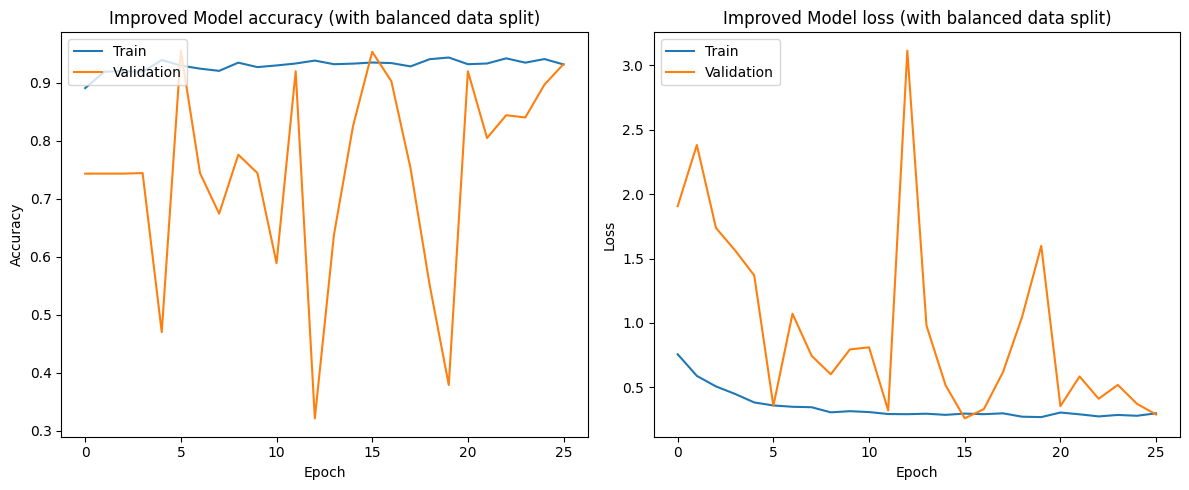

These plots show the training and validation accuracy and loss over epochs for the improved model with a balanced data split and class weights.


In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_improved.history['accuracy'])
plt.plot(history_improved.history['val_accuracy'])
plt.title('Improved Model accuracy (with balanced data split)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_improved.history['loss'])
plt.plot(history_improved.history['val_loss'])
plt.title('Improved Model loss (with balanced data split)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

print("These plots show the training and validation accuracy and loss over epochs for the improved model with a balanced data split and class weights.")


## 5.4 Model Evaluation (Improved Model)

Evaluating improved model on new test data...
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step - accuracy: 0.7750 - auc_1: 0.9380 - loss: 0.6263 - precision_1: 0.7387 - recall_1: 0.9874

Test Loss (Improved): 0.6263
Test Accuracy (Improved): 0.7750
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 237ms/step

Calculated Metrics (Improved Model on New Test Set):
Accuracy: 0.7750
Precision: 0.7387
Recall: 0.9874
F1-Score: 0.8452
AUC: 0.9378


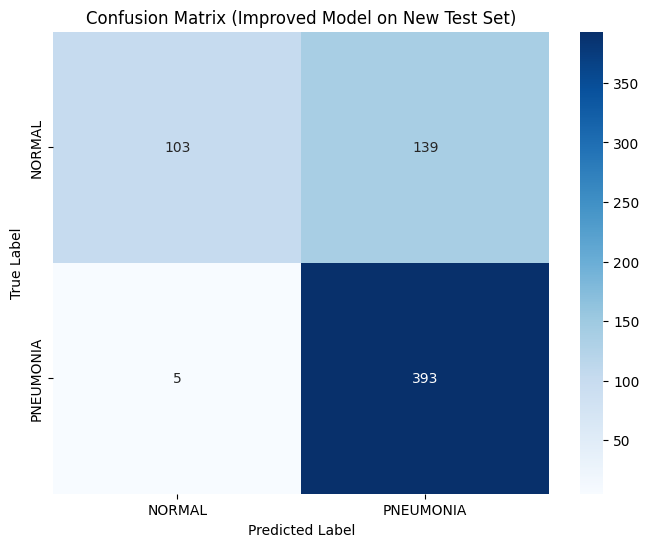

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns

print("Evaluating improved model on new test data...")

# Evaluate the improved model on the test set
loss_improved, accuracy_improved, precision_metric_improved, recall_metric_improved, auc_metric_improved = model_improved.evaluate(new_test_generator)
print(f"\nTest Loss (Improved): {loss_improved:.4f}")
print(f"Test Accuracy (Improved): {accuracy_improved:.4f}")

# Get predictions for the test set from the improved model
new_test_generator.reset()
Y_pred_proba_improved = model_improved.predict(new_test_generator)
Y_pred_improved = (Y_pred_proba_improved > 0.5).astype(int)

# Get true labels from the new test generator
Y_true_improved = new_test_generator.classes

# Calculate additional metrics for the improved model
acc_improved = accuracy_score(Y_true_improved, Y_pred_improved)
prec_improved = precision_score(Y_true_improved, Y_pred_improved)
rec_improved = recall_score(Y_true_improved, Y_pred_improved)
f1_improved = f1_score(Y_true_improved, Y_pred_improved)
auc_improved = roc_auc_score(Y_true_improved, Y_pred_proba_improved)
conf_matrix_improved = confusion_matrix(Y_true_improved, Y_pred_improved)

print(f"\nCalculated Metrics (Improved Model on New Test Set):")
print(f"Accuracy: {acc_improved:.4f}")
print(f"Precision: {prec_improved:.4f}")
print(f"Recall: {rec_improved:.4f}")
print(f"F1-Score: {f1_improved:.4f}")
print(f"AUC: {auc_improved:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_improved, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Improved Model on New Test Set)')
plt.show()


These weights will be passed to the `model.fit()` method during training. For example, if `class_weights_dict` is `{0: 1.5, 1: 0.75}`, it means misclassifying class `0` (NORMAL) will be penalized 1.5 times more than misclassifying class `1` (PNEUMONIA) because class 0 is the minority class.

#### Model Performance Interpretation (Improved Model)

**Evaluation Metrics**

After re-splitting the data, applying class weights, and incorporating Batch Normalization and L2 regularization, the improved model achieved the following on the new test set:

*   Test Loss (Improved): **0.6263**
*   Test Accuracy (Improved): **0.7750**
*   Precision (PNEUMONIA): **0.7387** - Out of all cases predicted as Pneumonia, **73.87%** were truly Pneumonia. This indicates that **26.13%** of the positive predictions were false positives (healthy patients incorrectly diagnosed with Pneumonia). This is lower than the previous model.
*   Recall (PNEUMONIA): **0.9874** - Out of all actual Pneumonia cases, **98.74%** were correctly identified. This is an exceptionally high recall score, meaning the model is very good at catching true Pneumonia cases, leading to a very low rate of False Negatives.
*   F1-Score: **0.8452** - This metric, balancing precision and recall, is still quite strong, but the drop from the previous model (0.8867) reflects the lower precision for Pneumonia.
*   AUC: **0.9378** - The Area Under the Curve remains excellent, suggesting the model has a very good overall ability to distinguish between Normal and Pneumonia cases.

* Confusion Matrix (Improved Model on New Test Set):

   True Positives (TP): **393** (Correctly identified Pneumonia cases)

  True Negatives (TN): **103** (Correctly identified Normal cases)
   
   False Positives (FP): **139** (Healthy patients incorrectly flagged as Pneumonia). This is a significant increase from the previous indicating a tendency to over-diagnose Pneumonia in healthy individuals.
   
  False Negatives (FN): **5** (Pneumonia patients incorrectly flagged as Normal). This is a substantial improvement from the previous showing the model is now much better at avoiding missed pneumonia diagnoses.

**Comparison:**

Compared to the initial model, the improved model has made a clear trade-off:

*   **Pros:** Significantly reduced False Negatives for Pneumonia (from 30 to 5), meaning fewer actual pneumonia cases are missed. T
*   **Cons:** Significantly increased False Positives for Pneumonia (from 62 to 139), meaning more healthy individuals are incorrectly diagnosed.

The overall accuracy has decreased (from 0.8526 to 0.7750), primarily due to the higher number of false positives for the `NORMAL` class. The increased weight for the `NORMAL` class during training seems to have resulted in the model trying very hard not to miss any `NORMAL` cases, which ironically led it to be overly cautious and predict `PNEUMONIA` more often when uncertain.

**Conclusion:** While the improved model is excellent at detecting all instances of Pneumonia, its tendency to incorrectly label healthy individuals as having Pneumonia could be problematic in a real-world setting.So,further tuning might be necessary.

### 5.5 Adjusting threshold

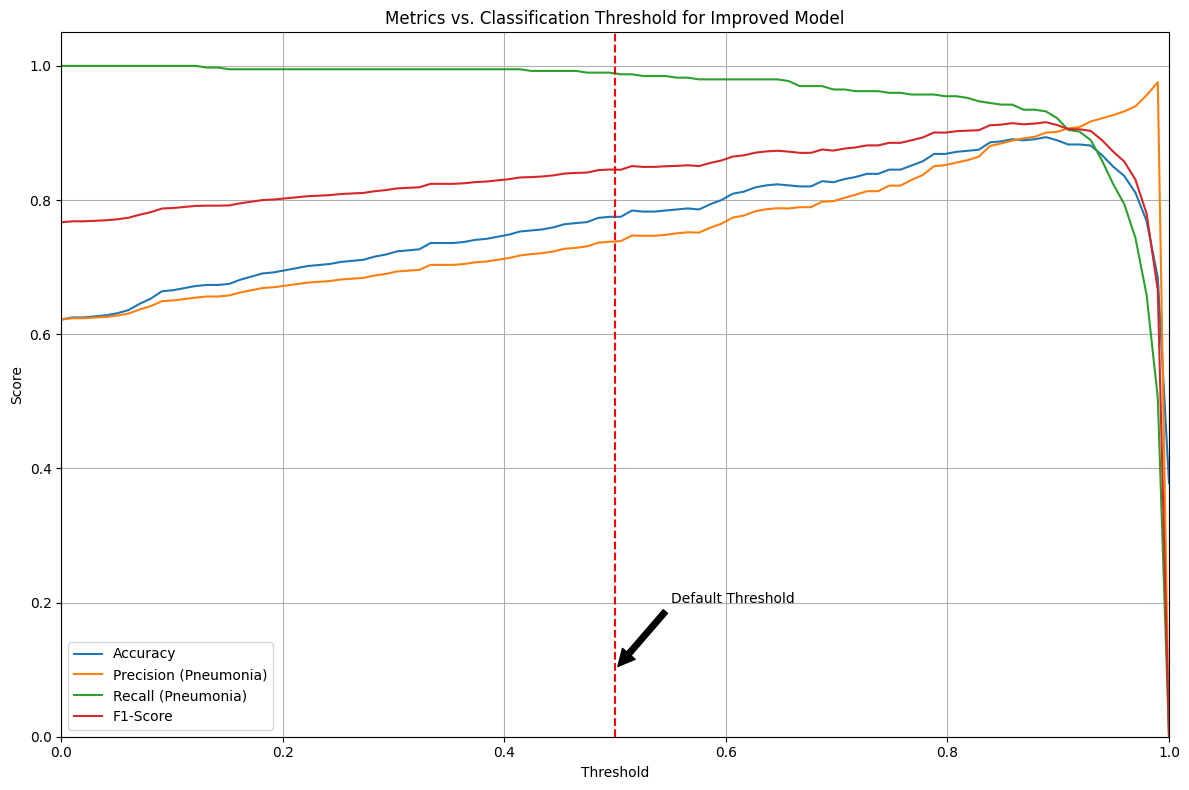

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming Y_pred_proba_improved and Y_true_improved are available from previous cells
# Y_pred_proba_improved contains the prediction probabilities from the improved model
# Y_true_improved contains the true labels for the new test set

thresholds = np.linspace(0, 1, 100) # Generate 100 thresholds between 0 and 1

accuracies = []
precisions = []
recalls = []
f1_scores = []

for t in thresholds:
    # Convert probabilities to binary predictions based on the current threshold
    y_pred_thresholded = (Y_pred_proba_improved > t).astype(int)

    # Calculate metrics
    accuracies.append(accuracy_score(Y_true_improved, y_pred_thresholded))
    precisions.append(precision_score(Y_true_improved, y_pred_thresholded, zero_division=0))
    recalls.append(recall_score(Y_true_improved, y_pred_thresholded, zero_division=0))
    f1_scores.append(f1_score(Y_true_improved, y_pred_thresholded, zero_division=0))

# Plotting the metrics
plt.figure(figsize=(12, 8))
plt.plot(thresholds, accuracies, label='Accuracy')
plt.plot(thresholds, precisions, label='Precision (Pneumonia)')
plt.plot(thresholds, recalls, label='Recall (Pneumonia)')
plt.plot(thresholds, f1_scores, label='F1-Score')

plt.title('Metrics vs. Classification Threshold for Improved Model')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.axvline(x=0.5, color='r', linestyle='--', label='Default Threshold (0.5)')
plt.annotate('Default Threshold', xy=(0.5, 0.1), xytext=(0.55, 0.2), arrowprops=dict(facecolor='black', shrink=0.05),)
plt.tight_layout()
plt.show()


The plot above shows how Accuracy, Precision, Recall, and F1-score for the Pneumonia class change as the classification threshold varies. We can observe the trade-offs:

*   **Recall** generally decreases as the threshold increases. A lower threshold means the model is more likely to classify a case as Pneumonia, thus catching more true positives.
*   **Precision** generally increases as the threshold increases. A higher threshold means the model is more conservative in classifying a case as Pneumonia, leading to fewer false positives.
*   **Accuracy** and **F1-Score** tend to peak at an optimal threshold where there is a good balance between precision and recall.

From this plot, we can visually identify a threshold that might offer a better balance between minimizing False Negatives (high recall) and minimizing False Positives (high precision), depending on the specific priorities for this medical diagnostic task. For example, if we want to prioritize minimizing false negatives, we might choose a lower threshold. If we want to prioritize minimizing false positives, we might choose a higher threshold.


Metrics with Optimal Threshold (0.7):
Accuracy: 0.8266
Precision: 0.7983
Recall: 0.9648
F1-Score: 0.8737


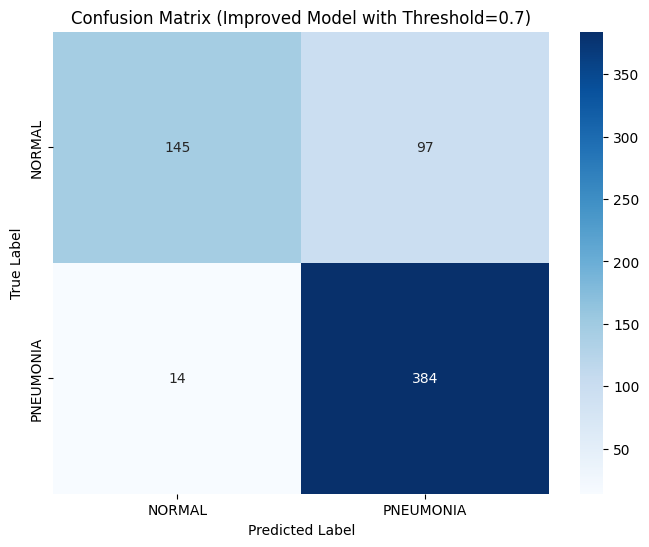

In [32]:
# Choose a new optimal threshold, e.g., 0.70
optimal_threshold = 0.70

# Convert probabilities to binary predictions using the new threshold
Y_pred_optimal = (Y_pred_proba_improved > optimal_threshold).astype(int)

# Calculate metrics with the optimal threshold
acc_optimal = accuracy_score(Y_true_improved, Y_pred_optimal)
prec_optimal = precision_score(Y_true_improved, Y_pred_optimal, zero_division=0)
rec_optimal = recall_score(Y_true_improved, Y_pred_optimal, zero_division=0)
f1_optimal = f1_score(Y_true_improved, Y_pred_optimal, zero_division=0)
conf_matrix_optimal = confusion_matrix(Y_true_improved, Y_pred_optimal)

print(f"\nMetrics with Optimal Threshold ({optimal_threshold}):")
print(f"Accuracy: {acc_optimal:.4f}")
print(f"Precision: {prec_optimal:.4f}")
print(f"Recall: {rec_optimal:.4f}")
print(f"F1-Score: {f1_optimal:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_optimal, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (Improved Model with Threshold={optimal_threshold})')
plt.show()


#### Interpretation with Optimal Threshold

This new threshold **0.70** provides a trade-off. While it might lead to a slight increase in False Negatives for Pneumonia (missing a few more cases), it significantly reduces False Positives for Pneumonia, making the model more reliable in confidently identifying healthy individuals. The choice of the 'optimal' threshold ultimately depends on the specific clinical priorities and the acceptable balance between these types of errors.